In [1]:
import torch.nn as nn
import torch
import torch.optim as optim
import copy
from helper_functions.data_loading.data_utils import get_dataloaders
from torchvision import models
DATA_DIR = "dataset/garbage_classification"

In [2]:

# device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)

# data
train_loader, val_loader, test_loader, class_names, class_weights = get_dataloaders(DATA_DIR)

# model
# reuse the same data + device from before; re-run get_dataloaders if needed
# train_loader, val_loader, test_loader, class_names, class_weights = get_dataloaders(DATA_DIR)

weights = models.MobileNet_V2_Weights.IMAGENET1K_V1     # pretrained on ImageNet
tmodel = models.mobilenet_v2(weights=weights)           # first run downloads ~14MB

# replace the final classifier layer: 1280 features -> your 12 classes
tmodel.classifier[1] = nn.Linear(tmodel.last_channel, len(class_names))

# freeze the pretrained body, keep only the new head trainable
for p in tmodel.features.parameters():
    p.requires_grad = False

tmodel = tmodel.to(device)

device: mps
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /Users/mukundanramesh/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:01<00:00, 11.9MB/s]


In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=15):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())

    for epoch in range(1, epochs + 1):
        # ---- train ----
        model.train()
        run_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            run_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
        train_loss, train_acc = run_loss / total, correct / total

        # ---- validate ----
        model.eval()
        run_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                run_loss += loss.item() * imgs.size(0)
                correct += (outputs.argmax(1) == labels).sum().item()
                total += labels.size(0)
        val_loss, val_acc = run_loss / total, correct / total

        for k, v in zip(history, [train_loss, val_loss, train_acc, val_acc]):
            history[k].append(v)

        print(f"Epoch {epoch:2d}/{epochs} | train_loss {train_loss:.3f} acc {train_acc:.3f} "
              f"| val_loss {val_loss:.3f} acc {val_acc:.3f}")

        if val_acc > best_val_acc:                       # keep the best version, not the last
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_weights)
    print(f"Best val acc: {best_val_acc:.3f}")
    return model, history

In [ ]:
# device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)

# data
train_loader, val_loader, test_loader, class_names, class_weights = get_dataloaders(DATA_DIR)

# model
model = BaselineCNN(num_classes=len(class_names)).to(device)

# loss (with class weights) + optimizer
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)

device: mps
BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): AdaptiveAvgPool2d(output_size=(4, 4))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=12, bias=True)
  )
)


In [8]:
trained_model, history = train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=2)

Epoch  1/2 | train_loss 1.807 acc 0.395 | val_loss 1.429 acc 0.505
Epoch  2/2 | train_loss 1.428 acc 0.525 | val_loss 1.282 acc 0.613
Best val acc: 0.613


In [9]:
model, history = train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=15)

Epoch  1/15 | train_loss 1.300 acc 0.576 | val_loss 1.211 acc 0.633
Epoch  2/15 | train_loss 1.199 acc 0.611 | val_loss 1.130 acc 0.678
Epoch  3/15 | train_loss 1.122 acc 0.634 | val_loss 1.120 acc 0.689
Epoch  4/15 | train_loss 1.047 acc 0.664 | val_loss 1.031 acc 0.710
Epoch  5/15 | train_loss 1.007 acc 0.676 | val_loss 1.026 acc 0.716
Epoch  6/15 | train_loss 0.957 acc 0.693 | val_loss 0.962 acc 0.712
Epoch  7/15 | train_loss 0.906 acc 0.707 | val_loss 0.934 acc 0.747
Epoch  8/15 | train_loss 0.888 acc 0.711 | val_loss 0.884 acc 0.740
Epoch  9/15 | train_loss 0.844 acc 0.729 | val_loss 0.922 acc 0.753
Epoch 10/15 | train_loss 0.800 acc 0.738 | val_loss 0.859 acc 0.742
Epoch 11/15 | train_loss 0.772 acc 0.747 | val_loss 0.834 acc 0.767
Epoch 12/15 | train_loss 0.745 acc 0.757 | val_loss 0.851 acc 0.763
Epoch 13/15 | train_loss 0.707 acc 0.768 | val_loss 0.873 acc 0.755
Epoch 14/15 | train_loss 0.696 acc 0.771 | val_loss 0.838 acc 0.782
Epoch 15/15 | train_loss 0.653 acc 0.781 | val_l

In [11]:
import os
import json

os.makedirs("models", exist_ok=True)
os.makedirs("reports/metrics", exist_ok=True)
os.makedirs("reports/figures", exist_ok=True)

torch.save(model.state_dict(), "models/baseline_cnn.pt")
with open("reports/metrics/baseline_history.json", "w") as f:
    json.dump(history, f, indent=2)

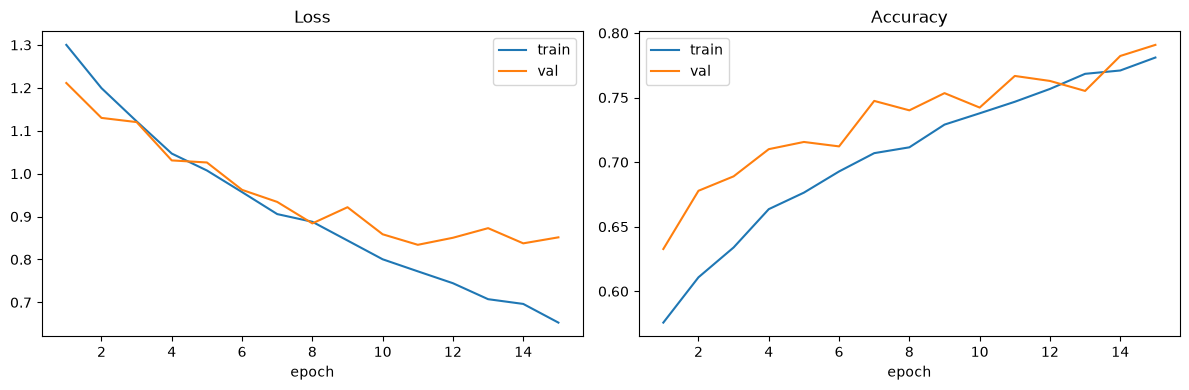

In [12]:
import matplotlib.pyplot as plt

ep = range(1, len(history["train_loss"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(ep, history["train_loss"], label="train")
ax[0].plot(ep, history["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()

ax[1].plot(ep, history["train_acc"], label="train")
ax[1].plot(ep, history["val_acc"], label="val")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()

plt.tight_layout()
os.makedirs("reports/figures", exist_ok=True)   # already covered above, safe to repeat
plt.savefig("reports/figures/baseline_curves.png", dpi=150)
plt.show()